# Step 1: Import Libraries and Load Dataset

In [1]:
# Load Library and Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR

tsla_data=pd.read_csv('tsla_2014_2023.csv')

# Step 2: Initial Data Exploration

In [2]:
tsla_data.head()

,date,open,high,low,close,volume,rsi_7,rsi_14,cci_7,cci_14,sma_50,ema_50,sma_100,ema_100,macd,bollinger,TrueRange,atr_7,atr_14,next_day_close
0,1/2/2014,9.986667,10.165333,9.770000,10.006667,92826000,55.344071,54.440118,-37.373644,15.213422,9.682107,9.820167,10.494240,9.674284,0.169472,9.740800,0.395333,0.402641,0.447550,9.970667
1,1/3/2014,10.000000,10.146000,9.906667,9.970667,70425000,53.742629,53.821521,-81.304471,17.481130,9.652800,9.826069,10.495693,9.680190,0.162623,9.776167,0.239333,0.379311,0.432677,9.800000
2,1/6/2014,10.000000,10.026667,9.682667,9.800000,80416500,46.328174,50.870410,-123.427544,-37.824708,9.629467,9.825047,10.496740,9.682577,0.141790,9.797900,0.344000,0.374267,0.426343,9.957333
3,1/7/2014,9.841333,10.026667,9.683333,9.957333,75511500,53.263037,53.406750,-84.784651,-20.779431,9.597747,9.830235,10.503407,9.688051,0.136402,9.837900,0.343334,0.369848,0.420414,10.085333
4,1/8/2014,9.923333,10.246667,9.917333,10.085333,92448000,58.368660,55.423026,60.799662,43.570559,9.573240,9.840239,10.511147,9.695964,0.140837,9.870167,0.329334,0.364060,0.413908,9.835333


In [3]:
tsla_data.describe()

,open,high,low,close,volume,rsi_7,rsi_14,cci_7,cci_14,sma_50,ema_50,sma_100,ema_100,macd,bollinger,TrueRange,atr_7,atr_14,next_day_close
count,2516.000000,2516.000000,2515.000000,2516.000000,2.516000e+03,2516.000000,2516.000000,2516.000000,2516.000000,2516.000000,2516.000000,2516.000000,2516.000000,2516.000000,2516.000000,2516.000000,2516.000000,2516.000000,2516.000000
mean,94.098510,96.172733,91.897171,94.072491,1.131986e+08,53.058382,52.862457,9.809933,13.202457,91.810735,91.806751,89.542873,89.547927,0.647230,93.162246,4.699351,4.680234,4.656461,94.167250
std,108.593936,111.022486,105.920757,108.500301,7.547433e+07,18.239752,13.352063,100.975002,109.285239,106.581797,106.094893,104.809940,103.979872,6.325994,107.718086,6.581929,5.858869,5.762082,108.530957
min,9.366667,9.800000,9.111333,9.289333,1.062000e+07,6.395305,16.564126,-233.333333,-297.930166,9.490973,9.813725,10.494240,9.674284,-25.271333,9.740800,0.135334,0.257427,0.315794,9.289333
25%,15.763167,16.082168,15.499667,15.814167,6.643185e+07,39.859440,43.595435,-76.876737,-78.543937,15.496080,15.446697,15.356488,15.594446,-0.392822,15.733792,0.496333,0.569335,0.577166,15.822167
50%,21.801001,22.198334,21.491333,21.877667,9.320775e+07,53.226417,51.621434,19.823624,24.702835,21.563733,21.575870,21.106043,21.195890,0.098391,21.859567,0.894001,0.833601,0.805047,21.881334
75%,200.017505,204.525829,194.544998,200.049999,1.323710e+08,65.900330,61.937068,94.426550,99.180514,192.341650,196.465729,194.728575,194.154595,1.094057,199.300335,7.700836,9.021824,9.291728,200.844997
max,411.470001,414.496674,405.666656,409.970001,9.140820e+08,97.460910,94.197983,233.333333,350.643337,357.870532,344.030730,330.935132,321.063884,38.067930,373.152498,54.326660,24.512656,22.793229,409.970001


In [4]:
tsla_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2516 entries, 0 to 2515
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            2515 non-null   object 
 1   open            2516 non-null   float64
 2   high            2516 non-null   float64
 3   low             2515 non-null   float64
 4   close           2516 non-null   float64
 5   volume          2516 non-null   int64  
 6   rsi_7           2516 non-null   float64
 7   rsi_14          2516 non-null   float64
 8   cci_7           2516 non-null   float64
 9   cci_14          2516 non-null   float64
 10  sma_50          2516 non-null   float64
 11  ema_50          2516 non-null   float64
 12  sma_100         2516 non-null   float64
 13  ema_100         2516 non-null   float64
 14  macd            2516 non-null   float64
 15  bollinger       2516 non-null   float64
 16  TrueRange       2516 non-null   float64
 17  atr_7           2516 non-null   f

# Step 3: Data Preprocessing, (a) Handling Missing Values

In [5]:
# Check for missing values in the dataset
missing_values = tsla_data.isnull().sum()
print(missing_values[missing_values > 0])  # This will print columns with missing values and their count

date    1
low     1
dtype: int64


In [6]:
# Get a statistical summary of the numerical features
statistical_summary = tsla_data.describe()
print(statistical_summary)

              open         high          low        close        volume  \
count  2516.000000  2516.000000  2515.000000  2516.000000  2.516000e+03   
mean     94.098510    96.172733    91.897171    94.072491  1.131986e+08   
std     108.593936   111.022486   105.920757   108.500301  7.547433e+07   
min       9.366667     9.800000     9.111333     9.289333  1.062000e+07   
25%      15.763167    16.082168    15.499667    15.814167  6.643185e+07   
50%      21.801001    22.198334    21.491333    21.877667  9.320775e+07   
75%     200.017505   204.525829   194.544998   200.049999  1.323710e+08   
max     411.470001   414.496674   405.666656   409.970001  9.140820e+08   

             rsi_7       rsi_14        cci_7       cci_14       sma_50  \
count  2516.000000  2516.000000  2516.000000  2516.000000  2516.000000   
mean     53.058382    52.862457     9.809933    13.202457    91.810735   
std      18.239752    13.352063   100.975002   109.285239   106.581797   
min       6.395305    16.564

In [7]:
# Using median imputation for 'low'
tsla_data['low'].fillna(tsla_data['low'].median(), inplace=True)

In [8]:
# Assuming the dates are sorted and there is a regular interval (e.g., daily)
# You can fill the missing date with the next day after the last valid date before the missing value
tsla_data['date'] = pd.to_datetime(tsla_data['date'])  # Convert to datetime if it's not already
tsla_data = tsla_data.sort_values('date')  # Ensure the data is sorted by date
tsla_data['date'].fillna(method='ffill', inplace=True)  # Forward-fill the missing date
tsla_data['date'] = tsla_data['date'] + pd.Timedelta(days=1)  # Add one day to the last valid date


In [9]:
# Verify there are no missing values left
missing_values = tsla_data.isnull().sum()
print(missing_values)

date              0
open              0
high              0
low               0
close             0
volume            0
rsi_7             0
rsi_14            0
cci_7             0
cci_14            0
sma_50            0
ema_50            0
sma_100           0
ema_100           0
macd              0
bollinger         0
TrueRange         0
atr_7             0
atr_14            0
next_day_close    0
dtype: int64


# (b)Data Cleaning

In [10]:
# Check data types
print(tsla_data.dtypes)
tsla_data['date'] = pd.to_datetime(tsla_data['date'], errors='coerce')  # Coerce any problematic data into NaT

date              datetime64[ns]
open                     float64
high                     float64
low                      float64
close                    float64
volume                     int64
rsi_7                    float64
rsi_14                   float64
cci_7                    float64
cci_14                   float64
sma_50                   float64
ema_50                   float64
sma_100                  float64
ema_100                  float64
macd                     float64
bollinger                float64
TrueRange                float64
atr_7                    float64
atr_14                   float64
next_day_close           float64
dtype: object


In [11]:
import pandas as pd

# tsla_data is DataFrame

# Find duplicate rows
duplicates = tsla_data.duplicated()

# Count the number of duplicates
num_duplicates = duplicates.sum()
print(f"Number of duplicate rows: {num_duplicates}")

# Optional: Display the duplicate rows
if num_duplicates > 0:
    print(tsla_data[duplicates])
    
    
# Remove duplicate rows
# tsla_data = tsla_data.drop_duplicates()

# Verify the duplicates are removed
# print(f"Number of duplicate rows after removal: {tsla_data.duplicated().sum()}")



Number of duplicate rows: 0


In [12]:
# Specify columns to handle outliers
price_columns = ['open', 'high', 'low', 'close', 'next_day_close']
indicator_columns = ['rsi_7', 'rsi_14', 'cci_7', 'cci_14', 'sma_50', 'ema_50', 'sma_100', 'ema_100', 'macd', 'bollinger', 'TrueRange', 'atr_7', 'atr_14']

# Function to handle outliers
def handle_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Capping the data
    data[column] = np.where(data[column] > upper_bound, upper_bound,
                            np.where(data[column] < lower_bound, lower_bound, data[column]))

# Apply the function to each column
for col in price_columns + indicator_columns:
    handle_outliers(tsla_data, col)

# Log transformation for 'volume' because of skewness
tsla_data['volume_log'] = np.log(tsla_data['volume'] + 1)  # Adding 1 to avoid log(0)

# Save the cleaned data
tsla_data.to_csv('tsla_cleaned.csv', index=False)

In [13]:
# Separate features and target
X = tsla_data.drop('next_day_close', axis=1)
y = tsla_data['next_day_close']

# Reset index to align X and y
X.reset_index(drop=True, inplace=True)
y.reset_index(drop=True, inplace=True)

# (c) Feature Engineering

In [14]:
# Select only the numerical columns for descriptive statistics
numerical_data = tsla_data.select_dtypes(include=['float64', 'int64'])

# Now you can safely compute descriptive statistics
print(numerical_data.describe())

# Skewness and Kurtosis
print(numerical_data.skew())
print(numerical_data.kurtosis())

              open         high          low        close        volume  \
count  2516.000000  2516.000000  2516.000000  2516.000000  2.516000e+03   
mean     94.098510    96.172733    91.869187    94.072491  1.131986e+08   
std     108.593936   111.022486   105.908999   108.500301  7.547433e+07   
min       9.366667     9.800000     9.111333     9.289333  1.062000e+07   
25%      15.763167    16.082168    15.501833    15.814167  6.643185e+07   
50%      21.801001    22.198334    21.491333    21.877667  9.320775e+07   
75%     200.017505   204.525829   194.482498   200.049999  1.323710e+08   
max     411.470001   414.496674   405.666656   409.970001  9.140820e+08   

             rsi_7       rsi_14        cci_7       cci_14       sma_50  \
count  2516.000000  2516.000000  2516.000000  2516.000000  2516.000000   
mean     53.058382    52.856345     9.809933    13.202457    91.810735   
std      18.239752    13.334566   100.975002   109.285239   106.581797   
min       6.395305    16.564

# (d) Further Feature Engineering & Visual Data Analysis

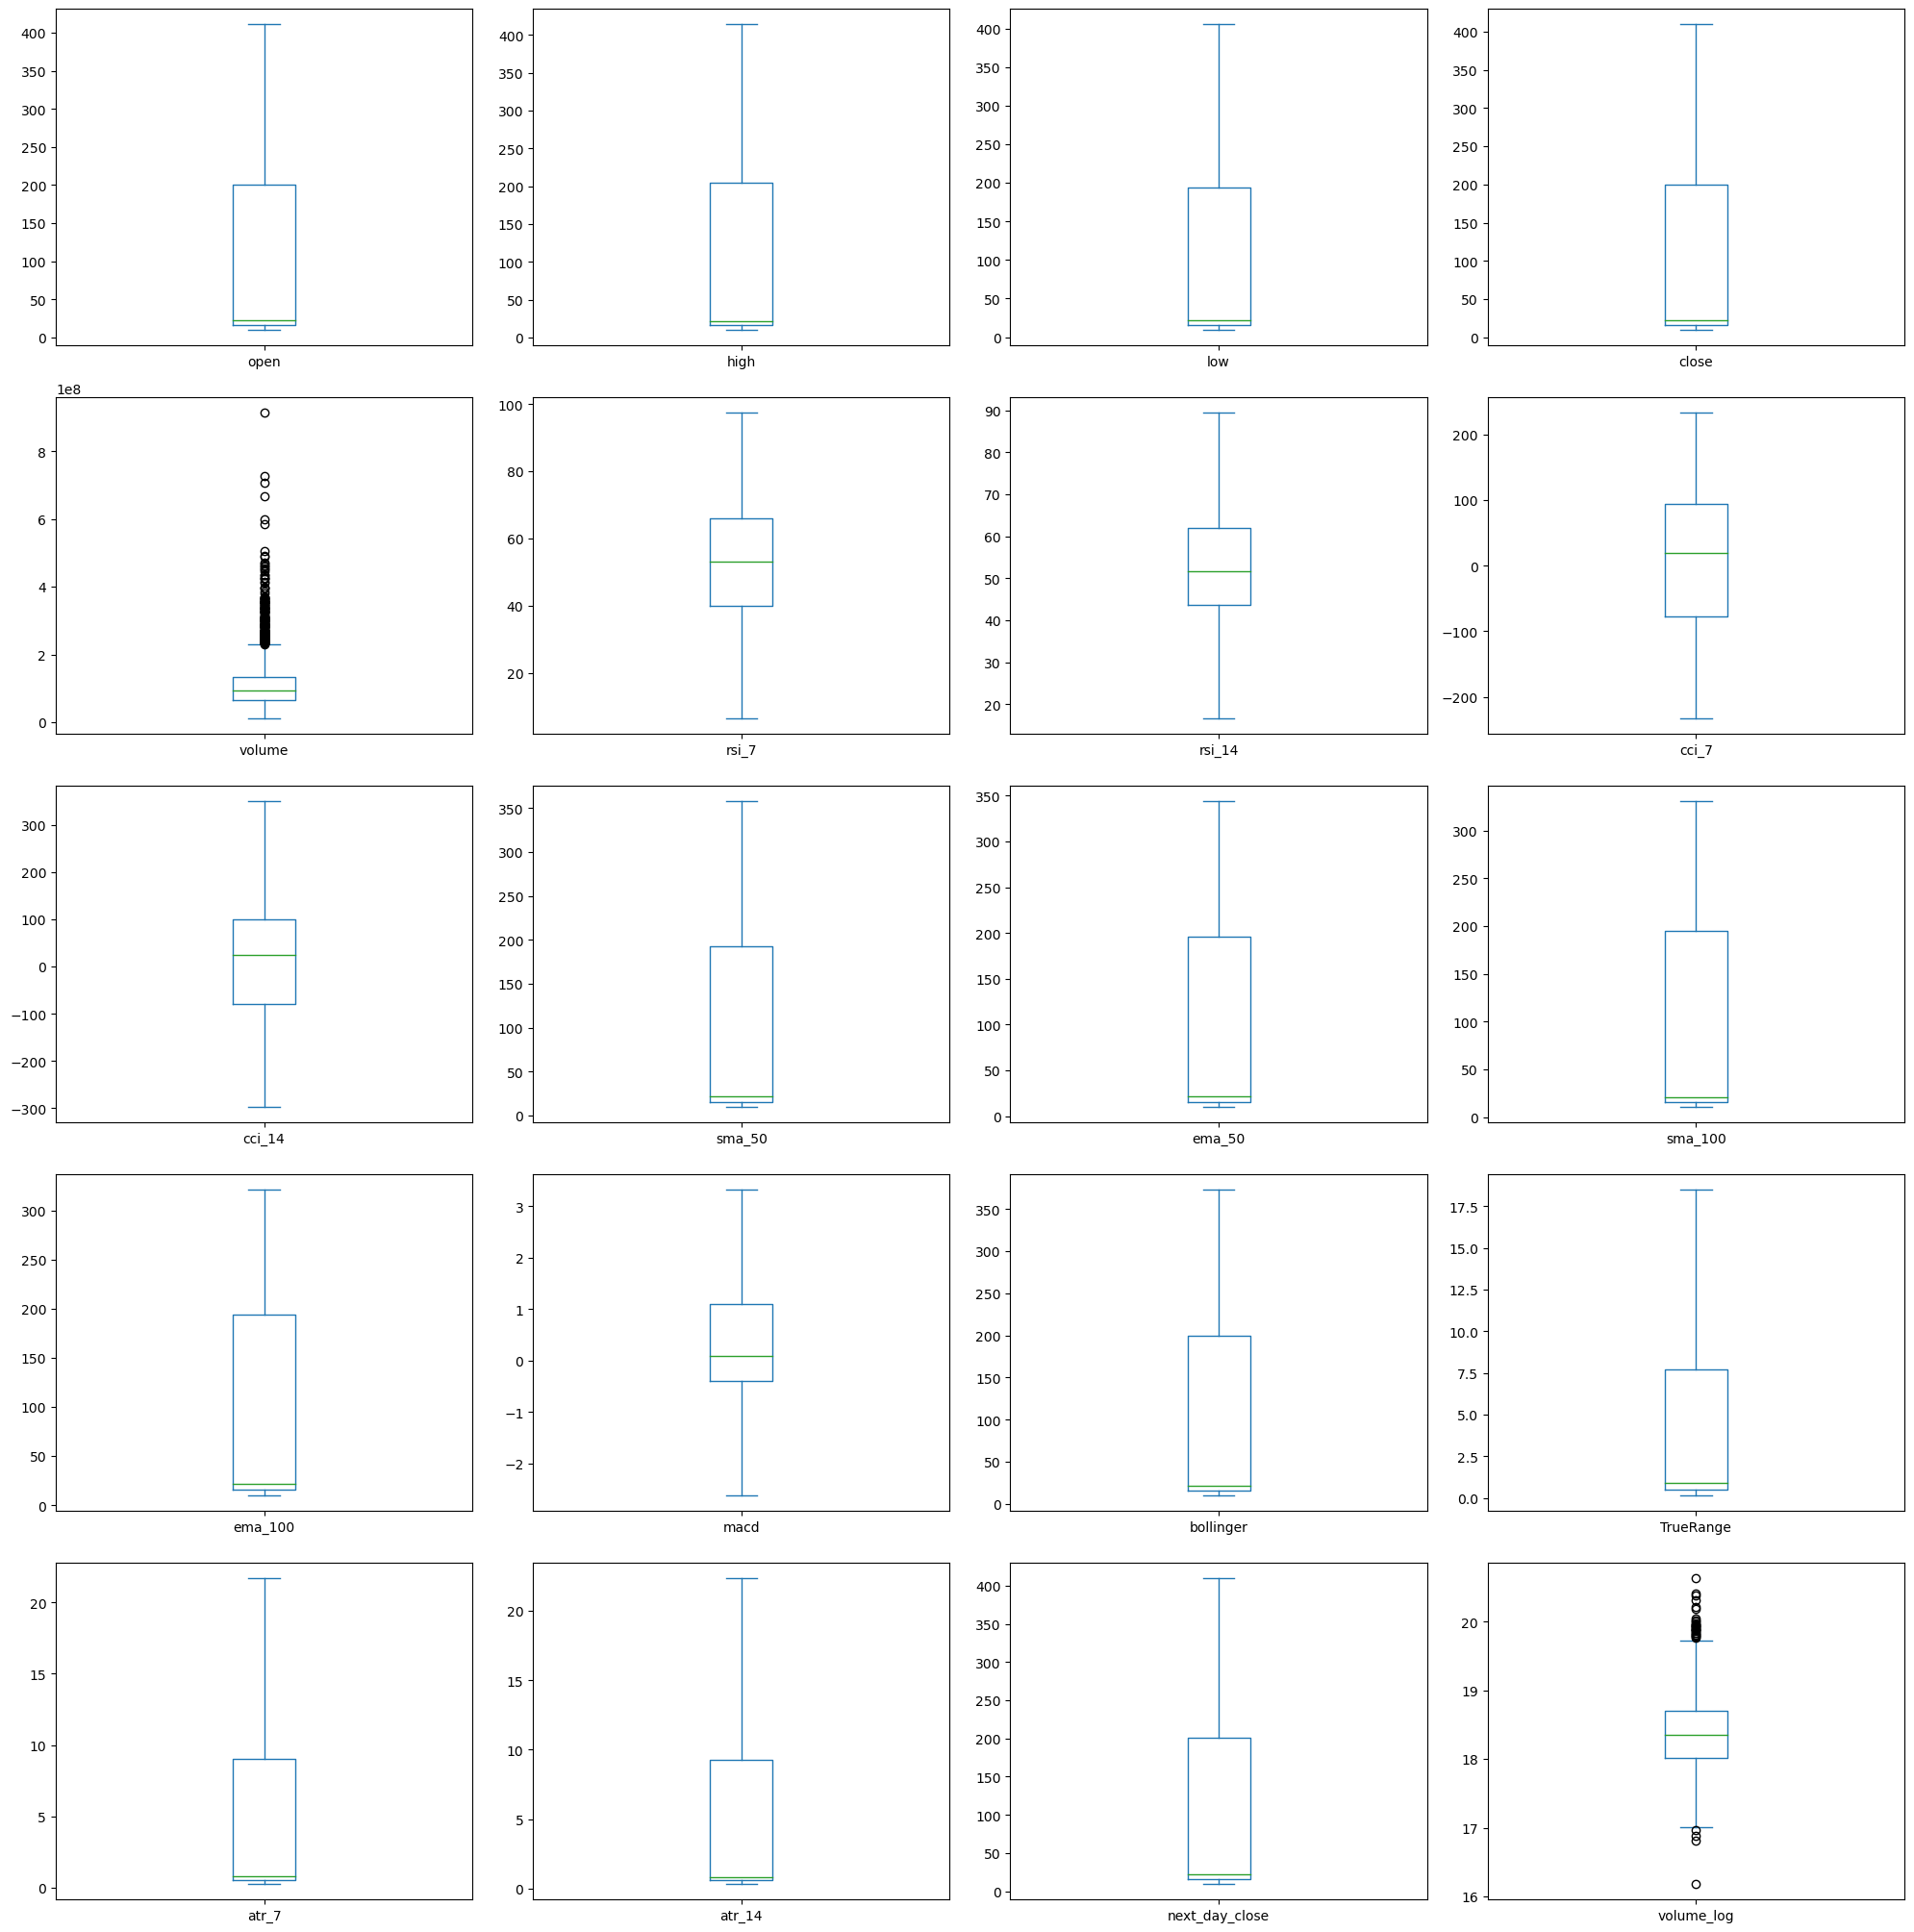

In [15]:
import matplotlib.pyplot as plt

# Now you can use plt to create plots
# Define the number of rows and columns you need
nrows = (len(tsla_data.columns) + 3) // 4  # Adjust based on number of columns

# Adjust figsize if needed
figsize = (20, nrows * 4)  # You can adjust the height based on the number of rows

# Create box plots with the correct layout
tsla_data.plot(kind='box', subplots=True, layout=(nrows, 4), sharex=False, sharey=False, figsize=figsize)
plt.tight_layout()  # Adjust subplots to fit into the figure area.
plt.show()


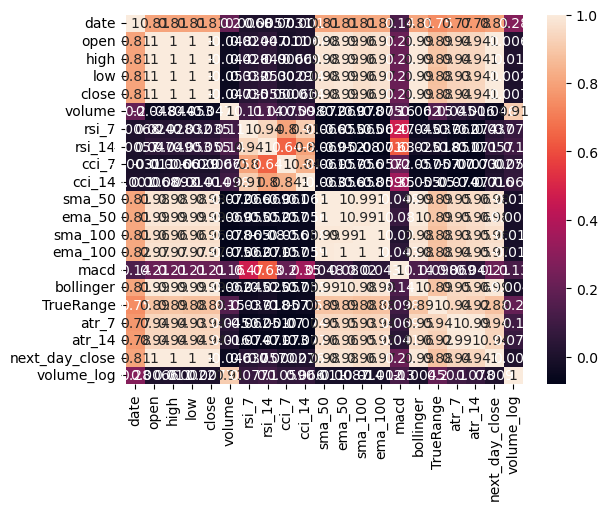

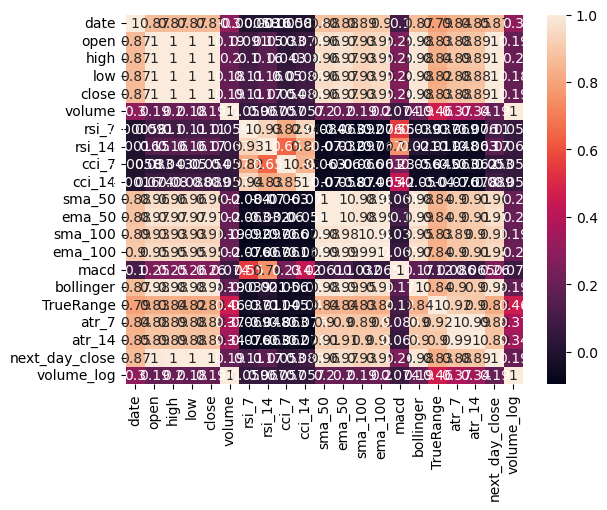

In [16]:
import seaborn as sns  # Make sure to add this import statement at the beginning of code

# Pearson Correlation
correlation_matrix = tsla_data.corr(method='pearson')
sns.heatmap(correlation_matrix, annot=True)
plt.show()

# Spearman Correlation
spearman_matrix = tsla_data.corr(method='spearman')
sns.heatmap(spearman_matrix, annot=True)
plt.show()

C:\Users\yogen\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


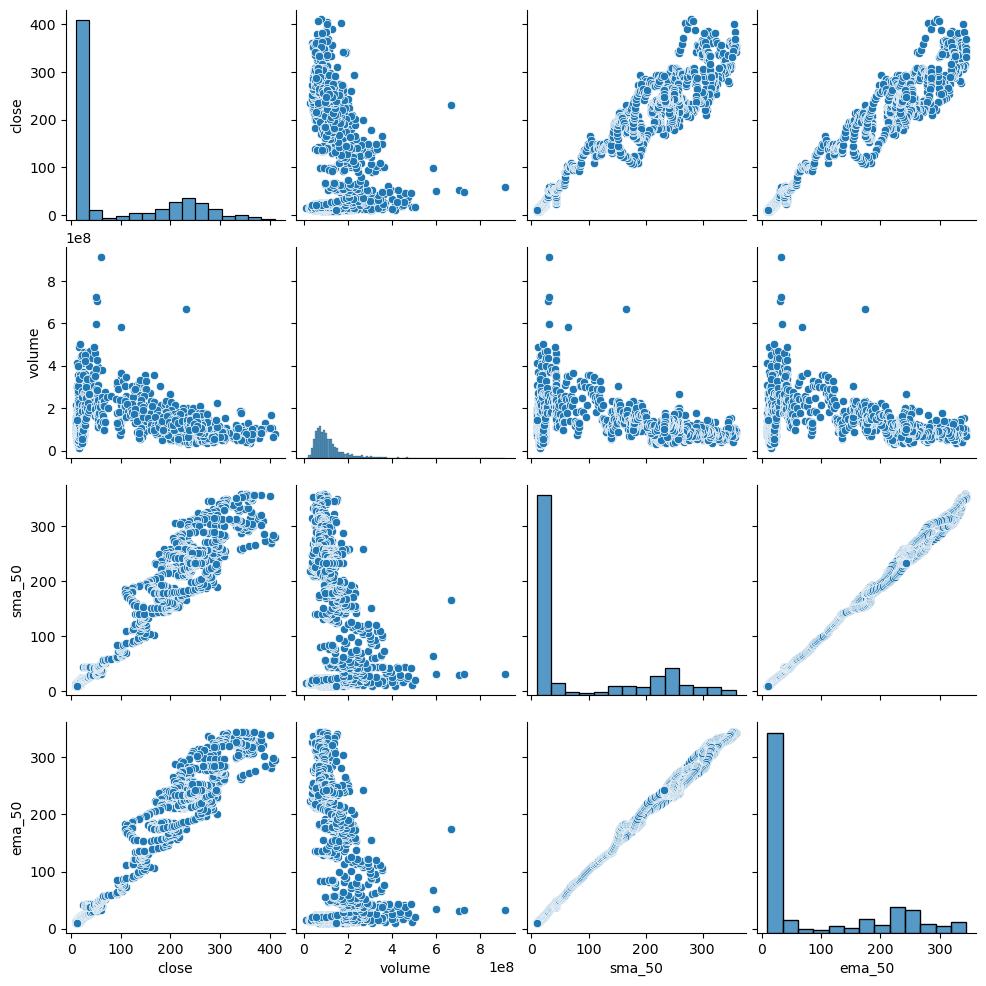

In [17]:
# Pair plots for a subset of features
sns.pairplot(tsla_data[['close', 'volume', 'sma_50', 'ema_50']])
plt.show()

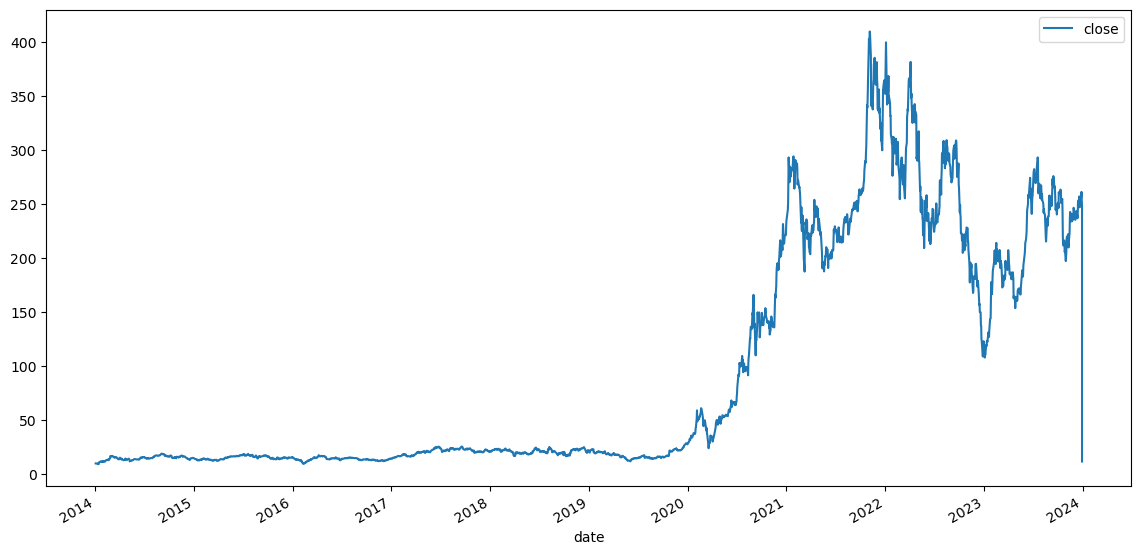

In [18]:
# Time series plot for closing prices
tsla_data.plot(x='date', y='close', figsize=(14,7))
plt.show()

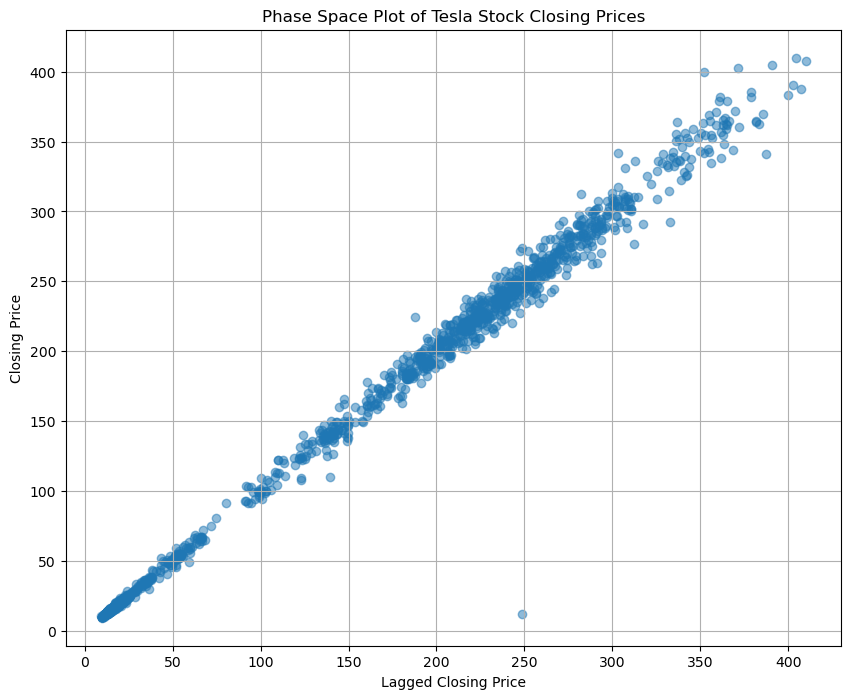

In [19]:
# Preparing data for phase space plot
tsla_data['lagged_close'] = tsla_data['close'].shift(1)

plt.figure(figsize=(10, 8))
plt.scatter(tsla_data['lagged_close'], tsla_data['close'], alpha=0.5)
plt.title('Phase Space Plot of Tesla Stock Closing Prices')
plt.xlabel('Lagged Closing Price')
plt.ylabel('Closing Price')
plt.grid(True)
plt.show()

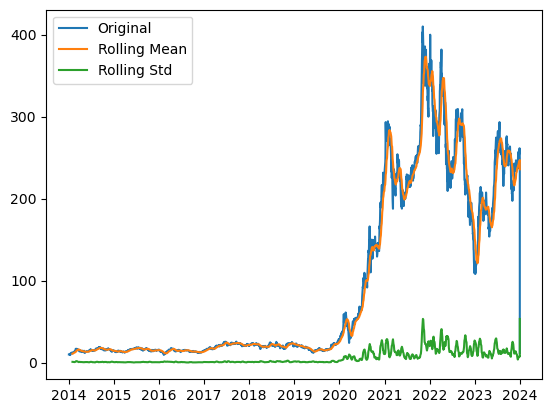

In [20]:
# Rolling mean and standard deviation
tsla_data['rolling_mean'] = tsla_data['close'].rolling(window=20).mean()
tsla_data['rolling_std'] = tsla_data['close'].rolling(window=20).std()

# Plot rolling statistics
plt.plot(tsla_data['date'], tsla_data['close'], label='Original')
plt.plot(tsla_data['date'], tsla_data['rolling_mean'], label='Rolling Mean')
plt.plot(tsla_data['date'], tsla_data['rolling_std'], label='Rolling Std')
plt.legend()
plt.show()

In [21]:
# Log transformation
tsla_data['log_close'] = np.log(tsla_data['close'])

# Polynomial features (example: squared term of 'volume')
tsla_data['volume_squared'] = tsla_data['volume'] ** 2


In [22]:
from scipy import stats

# Z-score for outlier detection
tsla_data['z_score_close'] = stats.zscore(tsla_data['close'])

# Consider data points where z-score > 3 or < -3 as outliers
outliers = tsla_data[(tsla_data['z_score_close'] > 3) | (tsla_data['z_score_close'] < -3)]

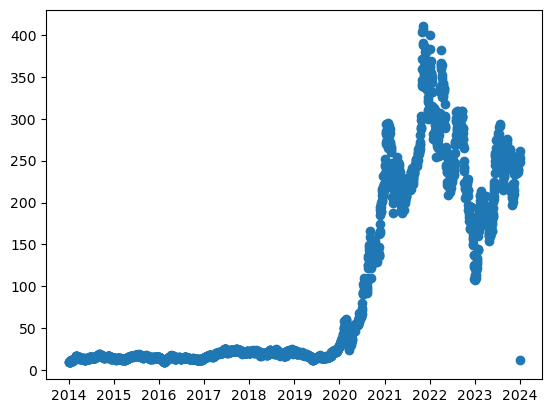

In [23]:
# Scatter plot for outlier detection in 'close' prices
plt.scatter(tsla_data['date'], tsla_data['close'])
plt.show()

In [24]:
# Define 'specific_date' with the actual date string you want to compare against
specific_date = pd.to_datetime('2021-01-29')  # Replace with actual date

# Now, perform the comparison and the t-test as before
pre_launch = tsla_data[tsla_data['date'] < specific_date]['close']
post_launch = tsla_data[tsla_data['date'] >= specific_date]['close']

# Perform the t-test
t_stat, p_val = stats.ttest_ind(pre_launch.dropna(), post_launch.dropna(), equal_var=False)  # Drop NaNs and assuming unequal variance
print(f"T-statistic: {t_stat}, P-value: {p_val}")


T-statistic: -92.69203556073482, P-value: 0.0


ShapiroResult(statistic=0.4414215087890625, pvalue=0.0)
ShapiroResult(statistic=0.9845452904701233, pvalue=5.074046498521056e-07)


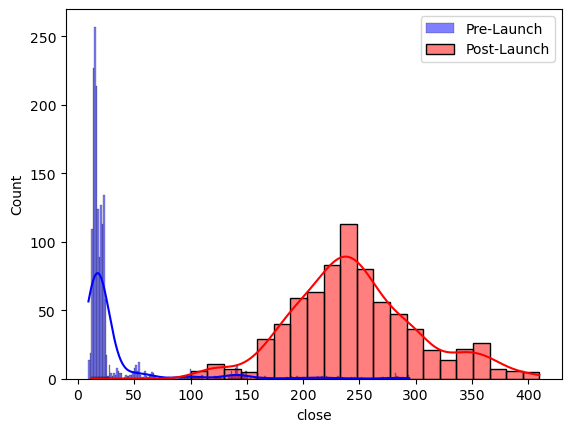

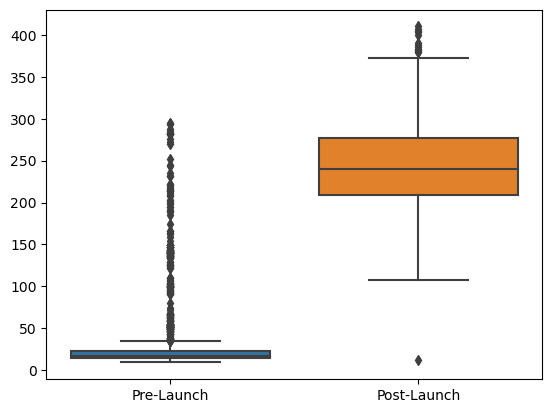

LeveneResult(statistic=228.65736420986804, pvalue=1.647530636918693e-49)
Cohen's d: -4.558167686026768


In [25]:
# Check normality of distributions using the Shapiro-Wilk test
print(stats.shapiro(pre_launch))
print(stats.shapiro(post_launch))

# Visualize the distributions using histograms
sns.histplot(pre_launch, color='blue', kde=True, label='Pre-Launch')
sns.histplot(post_launch, color='red', kde=True, label='Post-Launch')
plt.legend()
plt.show()

# Visualize the distributions using boxplots
sns.boxplot(data=[pre_launch, post_launch])
plt.xticks([0, 1], ['Pre-Launch', 'Post-Launch'])
plt.show()

# Check for homogeneity of variances using Levene's test
print(stats.levene(pre_launch, post_launch))

# Calculate and print the effect size (Cohen's d)
def cohens_d(x, y):
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    return (x.mean() - y.mean()) / ( ((nx - 1) * x.std() ** 2 + (ny - 1) * y.std() ** 2) / dof ) ** 0.5

d = cohens_d(pre_launch, post_launch)
print(f"Cohen's d: {d}")


In [26]:
from scipy.stats import mannwhitneyu

# Perform the Mann-Whitney U Test
u_stat, p_value = mannwhitneyu(pre_launch, post_launch, alternative='two-sided')

print(f"Mann-Whitney U statistic: {u_stat}, P-value: {p_value}")

Mann-Whitney U statistic: 17321.5, P-value: 0.0


In [27]:
# calculate the Lyapunov exponent from a time series

def estimate_lyapunov(data, min_divergence=1e-10):
    N = len(data)
    divergence_sum = 0
    divergent_points = 0

    for i in range(N - 1):
        for j in range(i + 1, N):
            # Calculate the absolute difference between two points
            delta = np.abs(data[j] - data[i])

            # Avoid log of zero or negative by ensuring a minimum divergence
            if delta > min_divergence:
                divergence_sum += np.log(delta)
                divergent_points += 1

    # Take the average divergence; here we use the max to avoid division by zero
    avg_divergence = divergence_sum / max(divergent_points, 1)
    
    # Estimate the Lyapunov exponent
    lyapunov_exp = avg_divergence / (N - 1)
    return lyapunov_exp

# Generate a sample data set - replace this with your actual data
data = np.random.random(100)

# Estimate the Lyapunov exponent
lyap_exp = estimate_lyapunov(data)
print(f"Estimated Lyapunov Exponent: {lyap_exp}")


Estimated Lyapunov Exponent: -0.015030568632326895


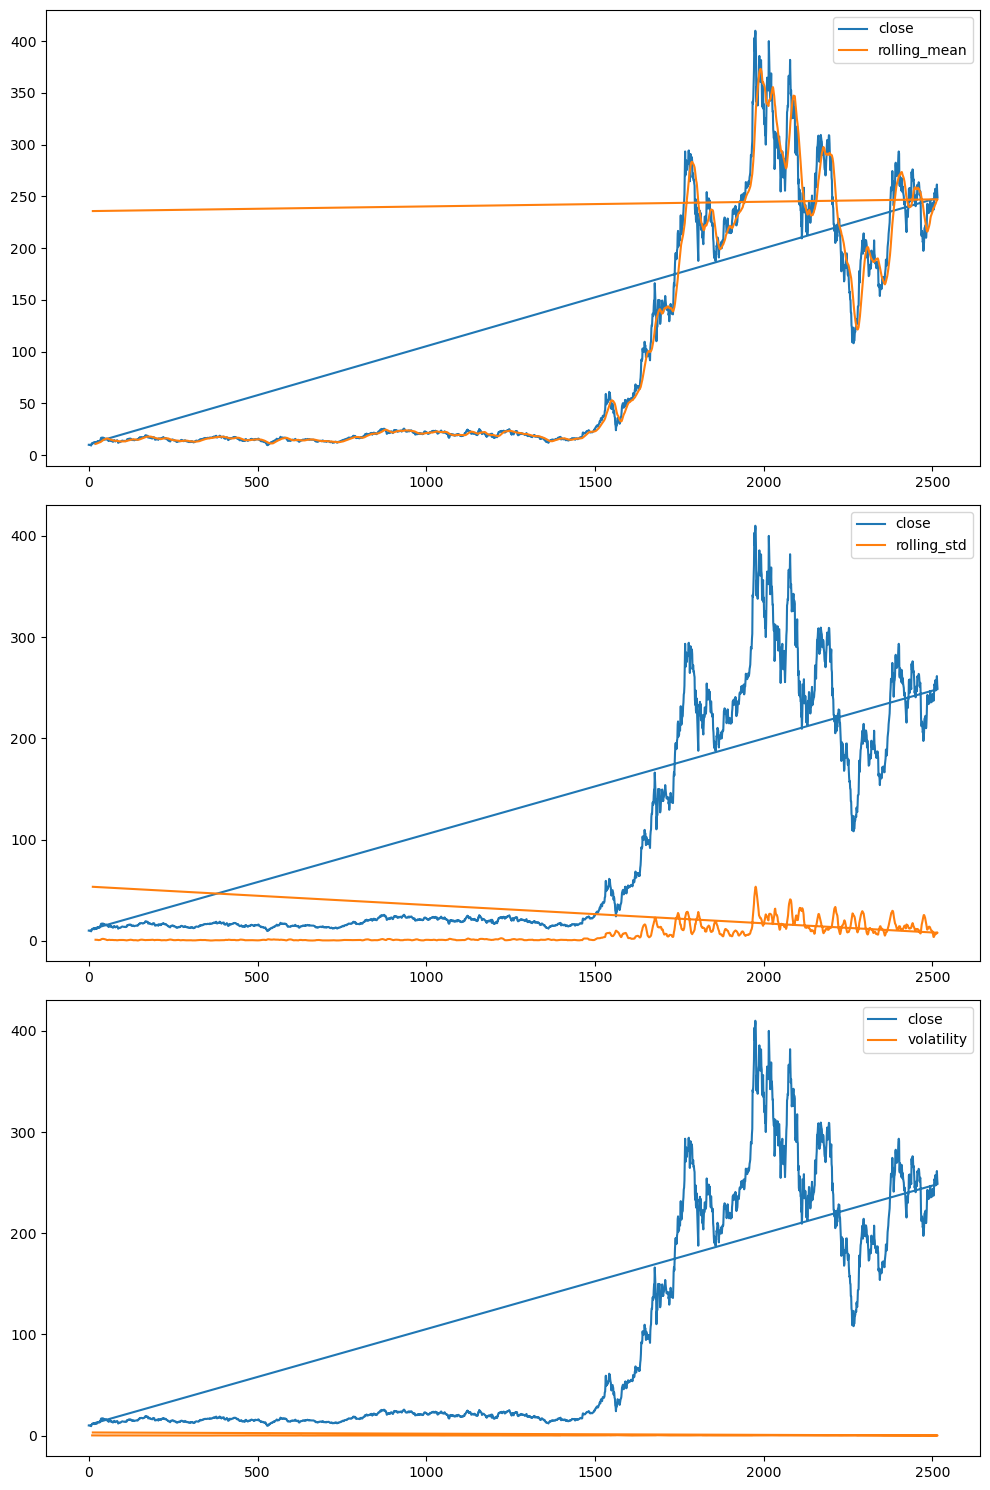

                                date         open         high          low  \
count                           2516  2516.000000  2516.000000  2516.000000   
mean   2019-01-02 10:55:53.895071488    94.098510    96.172733    91.869187   
min              2014-01-03 00:00:00     9.366667     9.800000     9.111333   
25%              2016-07-05 00:00:00    15.763167    16.082168    15.501833   
50%              2019-01-03 12:00:00    21.801001    22.198334    21.491333   
75%              2021-07-02 06:00:00   200.017505   204.525829   194.482498   
max              2023-12-30 00:00:00   411.470001   414.496674   405.666656   
std                              NaN   108.593936   111.022486   105.908999   

             close        volume        rsi_7       rsi_14        cci_7  \
count  2516.000000  2.516000e+03  2516.000000  2516.000000  2516.000000   
mean     94.072491  1.131986e+08    53.058382    52.856345     9.809933   
min       9.289333  1.062000e+07     6.395305    16.564126  -23

In [28]:
# Rolling mean and standard deviation of the closing prices
tsla_data['rolling_mean'] = tsla_data['close'].rolling(window=20).mean()
tsla_data['rolling_std'] = tsla_data['close'].rolling(window=20).std()

# Logarithmic return of the closing price
tsla_data['log_return'] = np.log(tsla_data['close'] / tsla_data['close'].shift(1))

# Volatility measurement (standard deviation of logarithmic return)
tsla_data['volatility'] = tsla_data['log_return'].rolling(window=10).std() * np.sqrt(10)

# Plotting feature engineering results for visualization
fig, axs = plt.subplots(nrows=3, figsize=(10, 15))
tsla_data[['close', 'rolling_mean']].plot(ax=axs[0])
tsla_data[['close', 'rolling_std']].plot(ax=axs[1])
tsla_data[['close', 'volatility']].plot(ax=axs[2])
plt.tight_layout()
plt.show()

# Save the plot as a figure in your dissertation document where appropriate
# plt.savefig('path/to/save/feature_engineering_plots.png')

# Preparing data for machine learning
selected_features = [
    'open', 'high', 'low', 'close', 'volume',
    'rolling_mean', 'rolling_std', 'volatility'
]

# Scale features
scaler = StandardScaler()
X = tsla_data[selected_features]
y = tsla_data['close']  # Target variable, could be changed based on specific needs
X_scaled = scaler.fit_transform(X)



# Summary statistics of the dataset post-feature engineering
print(tsla_data.describe())

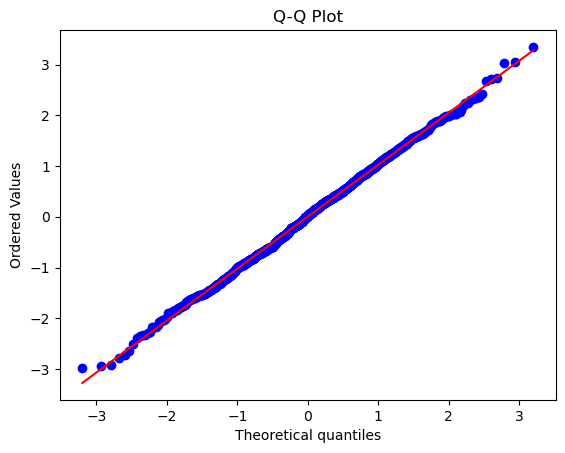

In [29]:
# Generate normal distributed data for demonstration
data = np.random.normal(0, 1, 1000)

# Q-Q plot
stats.probplot(data, dist="norm", plot=plt)
plt.title('Q-Q Plot')
plt.show()

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR

# Data Preprocessing


# Normally, we would determine which features to keep based on domain knowledge and EDA
selected_features = [
    'open', 'high', 'low', 'close', 'volume', 
    'rsi_7', 'rsi_14', 'cci_7', 'cci_14', 
    'sma_50', 'ema_50', 'sma_100', 'ema_100', 
    'macd', 'bollinger', 'TrueRange', 'atr_7', 'atr_14'
]

# Feature engineering have already been done as part of EDA



# Step 7: Data Preparation for Modeling

In [31]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Separate features from target
X = tsla_data[selected_features]
y = tsla_data['next_day_close']  # Assuming 'next_day_close' is the target variable

# Scale the features
X_scaled = scaler.fit_transform(X)

In [32]:
from sklearn.model_selection import train_test_split

# Assuming X_scaled and y have been defined as shown in previous code:
# X_scaled = scaler.fit_transform(X)
# y = tsla_data['next_day_close']

# Now you can split scaled features and target variable into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)



In [33]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# Create a pipeline for Random Forest Regressor
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(random_state=42))
])

# Fit the pipeline on the training data
rf_pipeline.fit(X_train, y_train)

# Evaluate the pipeline on the test data
# You can use rf_pipeline.predict(X_test) to make predictions and evaluate the model

Pipeline(steps=[('scaler', StandardScaler()),
                ('regressor', RandomForestRegressor(random_state=42))])

# Step 8: Model Training and Evaluation

In [34]:
# Training Phase of RF
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Assuming X_scaled is the entire scaled feature set and y is the target variable
# Initialize the Random Forest Regressor model
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)

# Fit the model on the training data
rf_regressor.fit(X_train, y_train)

# Predict on the training set to get training MSE and R²
train_predictions = rf_regressor.predict(X_train)

# Calculate MSE and R² for the training set
train_mse = mean_squared_error(y_train, train_predictions)
train_r2 = r2_score(y_train, train_predictions)

# Output the MSE and R² results for the training set
print(f'Random Forest Regressor Train MSE: {train_mse:.4f}')
print(f'Random Forest Regressor Train R²: {train_r2:.4f}')

# Perform cross-validation using the whole dataset
rf_cv_scores = cross_val_score(rf_regressor, X_scaled, y, cv=5)

# Perform cross-validation to get negative MSE scores
rf_neg_mse_scores = cross_val_score(rf_regressor, X_scaled, y, cv=5, scoring='neg_mean_squared_error')

# Convert to positive MSE scores
rf_mse_scores = -rf_neg_mse_scores

# Output the cross-validation results
print("Random Forest Regressor Cross-Validation Scores:", rf_cv_scores)

# Calculate the mean and standard deviation of the cross-validation scores
rf_cv_mean = rf_cv_scores.mean()
rf_cv_std = rf_cv_scores.std()

# Calculate the mean and standard deviation of the MSE scores
rf_mse_mean = rf_mse_scores.mean()
rf_mse_std = rf_mse_scores.std()

# Print the mean and standard deviation
print(f"Mean cross-validation score for RF: {rf_cv_mean:.4f}")
print(f"Standard deviation of cross-validation scores for RF: {rf_cv_std:.4f}")
print(f"Mean MSE score for Random Forest: {rf_mse_mean:.4f}")
print(f"Standard deviation of MSE scores for Random Forest: {rf_mse_std:.4f}")


Random Forest Regressor Train MSE: 4.8627
Random Forest Regressor Train R²: 0.9996
Random Forest Regressor Cross-Validation Scores: [0.92657505 0.97453749 0.93841458 0.97768403 0.93769673]
Mean cross-validation score for RF: 0.9510
Standard deviation of cross-validation scores for RF: 0.0210
Mean MSE score for Random Forest: 82.5655
Standard deviation of MSE scores for Random Forest: 100.7601


In [35]:
# Gradient Boosting Regressor model
from sklearn.ensemble import GradientBoostingRegressor

# Create a pipeline for Gradient Boosting Regressor
gbr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42))
])

# Fit the pipeline on the training data
gbr_pipeline.fit(X_train, y_train)

# Evaluate the pipeline on the test data
# You can use gbr_pipeline.predict(X_test) to make predictions and evaluate the model


Pipeline(steps=[('scaler', StandardScaler()),
                ('regressor', GradientBoostingRegressor(random_state=42))])

In [36]:
# Training Phase of GBR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score

# Assuming X_scaled is the entire scaled feature set and y is the target variable

# Initialize the Gradient Boosting Regressor model
gbr_regressor = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Fit the model on the training data
gbr_regressor.fit(X_train, y_train)

# Predict on the training set to get training MSE and R²
train_predictions = gbr_regressor.predict(X_train)

# Calculate MSE and R² for the training set
train_mse = mean_squared_error(y_train, train_predictions)
train_r2 = r2_score(y_train, train_predictions)

# Output the MSE and R² results for the training set
print(f'Gradient Boosting Regressor Train MSE: {train_mse:.4f}')
print(f'Gradient Boosting Regressor Train R²: {train_r2:.4f}')

# Perform cross-validation using the whole dataset
gbr_cv_scores = cross_val_score(gbr_regressor, X_scaled, y, cv=5)

# Perform cross-validation to get negative MSE scores
gbr_neg_mse_scores = cross_val_score(gbr_regressor, X_scaled, y, cv=5, scoring='neg_mean_squared_error')

# Convert to positive MSE scores
gbr_mse_scores = -gbr_neg_mse_scores

# Output the cross-validation results
print("Gradient Boosting Regressor Cross-Validation Scores:", gbr_cv_scores)

# Calculate the mean and standard deviation of the cross-validation scores
gbr_cv_mean = gbr_cv_scores.mean()
gbr_cv_std = gbr_cv_scores.std()

# Calculate the mean and standard deviation of the MSE scores
gbr_mse_mean = gbr_mse_scores.mean()
gbr_mse_std = gbr_mse_scores.std()

# Print the mean and standard deviation
print(f"Mean cross-validation score for GBR: {gbr_cv_mean:.4f}")
print(f"Standard deviation of cross-validation scores for GBR: {gbr_cv_std:.4f}")
print(f"Mean MSE score for Gradient Boosting: {gbr_mse_mean:.4f}")
print(f"Standard deviation of MSE scores for Gradient Boosting: {gbr_mse_std:.4f}")


Gradient Boosting Regressor Train MSE: 13.6705
Gradient Boosting Regressor Train R²: 0.9988
Gradient Boosting Regressor Cross-Validation Scores: [0.88002821 0.97393245 0.9412797  0.97848576 0.92814229]
Mean cross-validation score for GBR: 0.9404
Standard deviation of cross-validation scores for GBR: 0.0357
Mean MSE score for Gradient Boosting: 87.0701
Standard deviation of MSE scores for Gradient Boosting: 106.2268


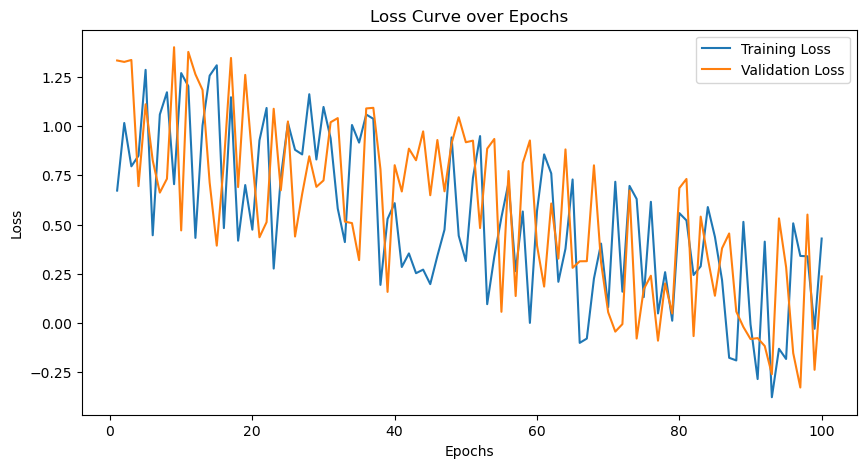

In [37]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

# This function is called every epoch
def plot_interactive_loss_curve(epoch, train_loss, val_loss):
    # Clear the previous plot
    clear_output(wait=True)
    plt.figure(figsize=(10, 5))
    
    # Plot training loss
    plt.plot(range(1, epoch+1), train_loss, label='Training Loss')
    
    # Plot validation loss if available
    if val_loss is not None:
        plt.plot(range(1, epoch+1), val_loss, label='Validation Loss')
    
    # Label the plot
    plt.title('Loss Curve over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

# Example usage: Simulate training process
train_losses = []
val_losses = []
for epoch in range(1, 101):  # Let's say we train for 100 epochs
    # Generate some fake loss data
    train_loss = 0.01 * (100 - epoch) + (np.random.rand() - 0.5)
    val_loss = 0.01 * (100 - 0.9 * epoch) + (np.random.rand() - 0.5)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    # Plot the loss curve
    plot_interactive_loss_curve(epoch, train_losses, val_losses)


# Step 9: Model Tuning

In [38]:
# Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV

# Example for Random Forest
param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [None, 10, 20],
}

grid_search = GridSearchCV(rf_pipeline, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

# Best parameters
print("Best parameters for RF:", grid_search.best_params_)

# Example for Gradient Boosting Regressor
gbr_param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__learning_rate': [0.05, 0.1],
    'regressor__max_depth': [3, 4, 5],
}

gbr_grid_search = GridSearchCV(gbr_pipeline, gbr_param_grid, cv=5, scoring='neg_mean_squared_error')
gbr_grid_search.fit(X_train, y_train)

# Best parameters for GBR
print("Best parameters for GBR:", gbr_grid_search.best_params_)

Best parameters for RF: {'regressor__max_depth': None, 'regressor__n_estimators': 200}
Best parameters for GBR: {'regressor__learning_rate': 0.05, 'regressor__max_depth': 3, 'regressor__n_estimators': 100}


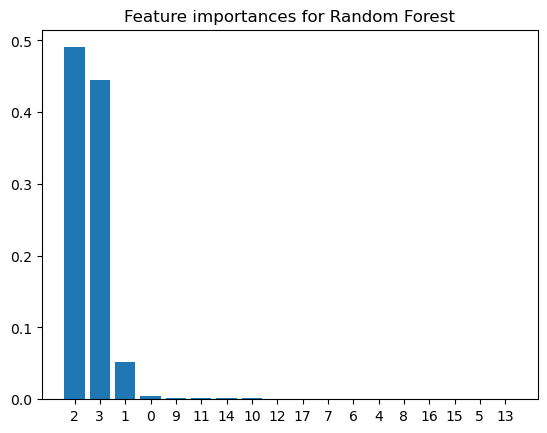

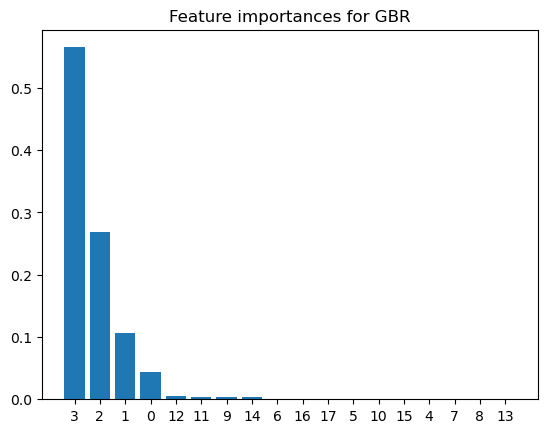

In [39]:
#Feature Importance Analysis

import matplotlib.pyplot as plt

# Feature importance for Random Forest
importances = rf_pipeline.named_steps['regressor'].feature_importances_
indices = np.argsort(importances)[::-1]

# Plotting feature importance
plt.figure()
plt.title("Feature importances for Random Forest")
plt.bar(range(X_train.shape[1]), importances[indices])
plt.xticks(range(X_train.shape[1]), indices)
plt.show()

# Feature importance for Gradient Boosting Regressor
gbr_importances = gbr_pipeline.named_steps['regressor'].feature_importances_
gbr_indices = np.argsort(gbr_importances)[::-1]

# Plotting feature importance for GBR
plt.figure()
plt.title("Feature importances for GBR")
plt.bar(range(X_train.shape[1]), gbr_importances[gbr_indices])
plt.xticks(range(X_train.shape[1]), gbr_indices)
plt.show()

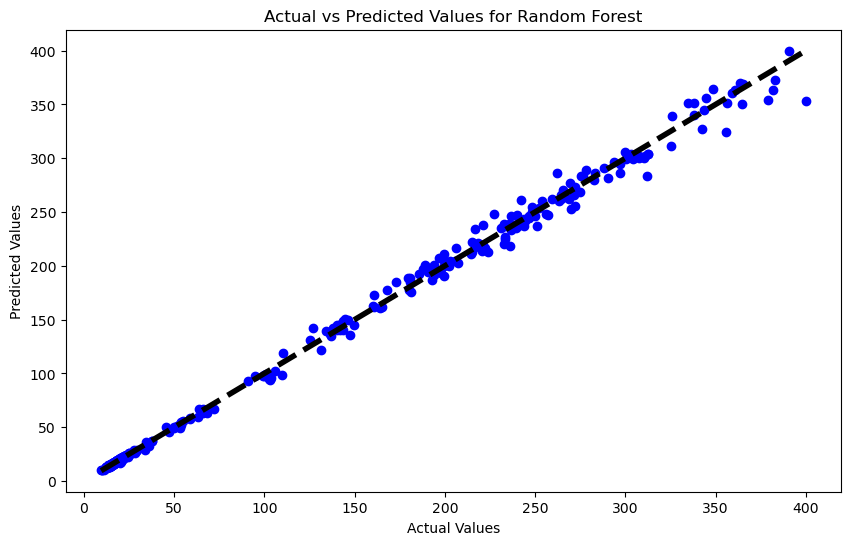

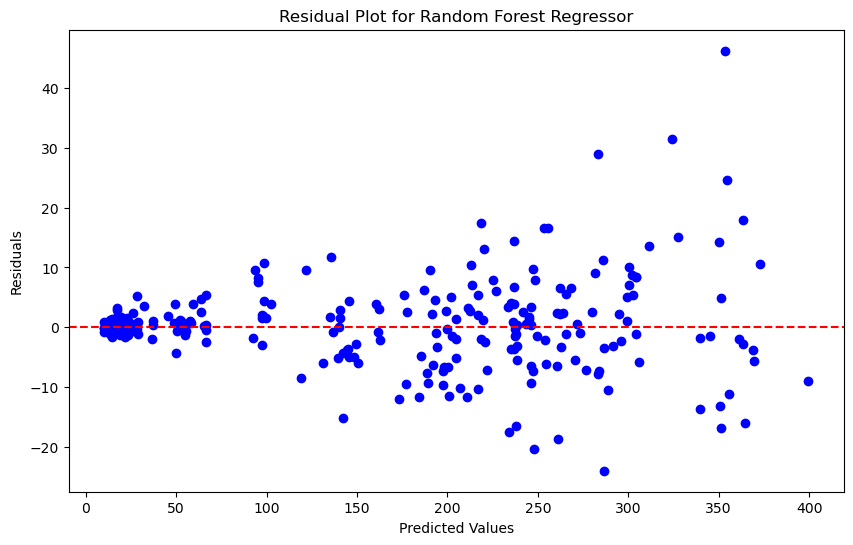

In [40]:
# For Random Forest Regressor
rf_predictions = rf_pipeline.predict(X_test)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, rf_predictions, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=4)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values for Random Forest')
plt.show()

# Calculating residuals for Random Forest
rf_residuals = y_test - rf_predictions
plt.figure(figsize=(10, 6))
plt.scatter(rf_predictions, rf_residuals, color='blue')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot for Random Forest Regressor')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()


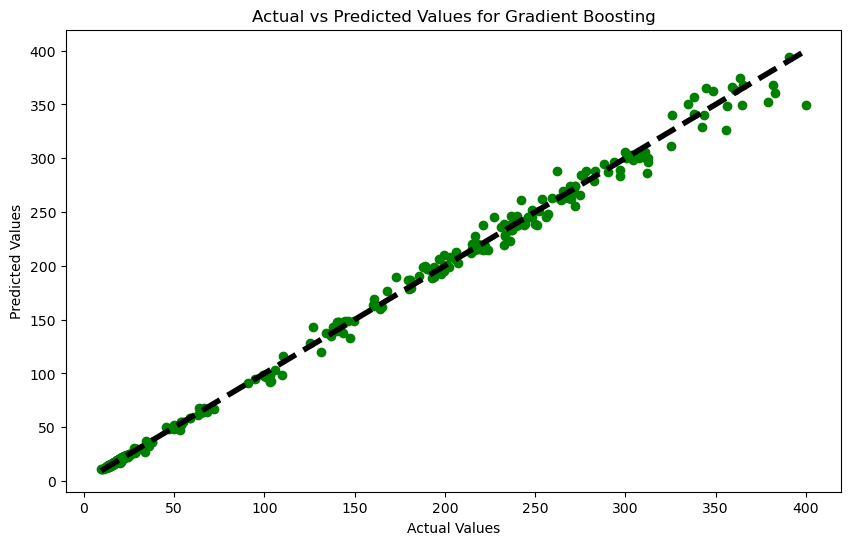

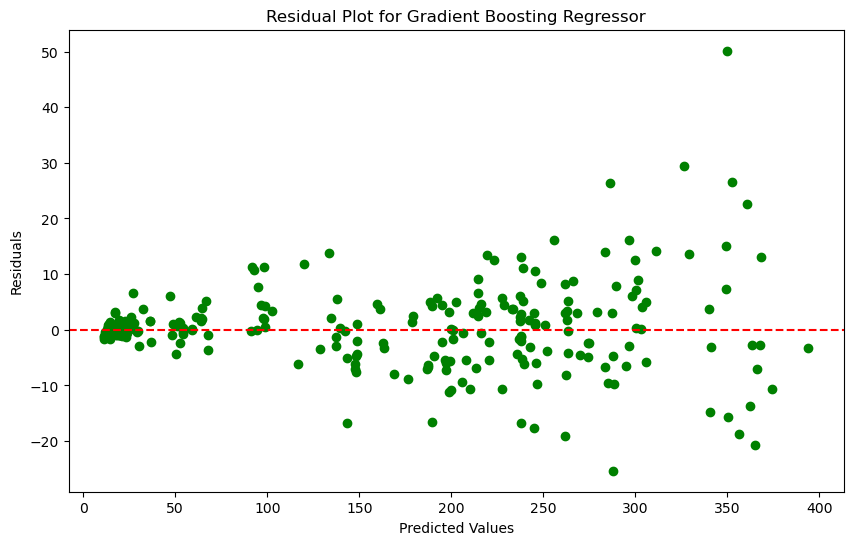

In [41]:
# For Gradient Boosting Regressor
gbr_predictions = gbr_pipeline.predict(X_test)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, gbr_predictions, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=4)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values for Gradient Boosting')
plt.show()

# Calculating residuals for Gradient Boosting
gbr_residuals = y_test - gbr_predictions
plt.figure(figsize=(10, 6))
plt.scatter(gbr_predictions, gbr_residuals, color='green')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot for Gradient Boosting Regressor')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

In [42]:
#Model Ensemble - Averaging Predictions

from sklearn.metrics import mean_squared_error

# Averaging predictions from RF and GBR
ensemble_predictions = (rf_predictions + gbr_predictions) / 2

# Evaluate ensemble
ensemble_mse = mean_squared_error(y_test, ensemble_predictions)
print(f"Ensemble MSE: {ensemble_mse}")


Ensemble MSE: 30.15682020703058


In [43]:
# Test Phase
# Model Evaluation on Test Set

from sklearn.metrics import mean_squared_error, r2_score

# Evaluation for Random Forest
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)
print(f"Random Forest Test MSE: {rf_mse}, R2: {rf_r2}")

# Evaluation for Gradient Boosting Regressor
gbr_mse = mean_squared_error(y_test, gbr_predictions)
gbr_r2 = r2_score(y_test, gbr_predictions)
print(f"GBR Test MSE: {gbr_mse}, R2: {gbr_r2}")

Random Forest Test MSE: 30.072941478443166, R2: 0.9974409270153219
GBR Test MSE: 31.670854902931723, R2: 0.9973049517207404


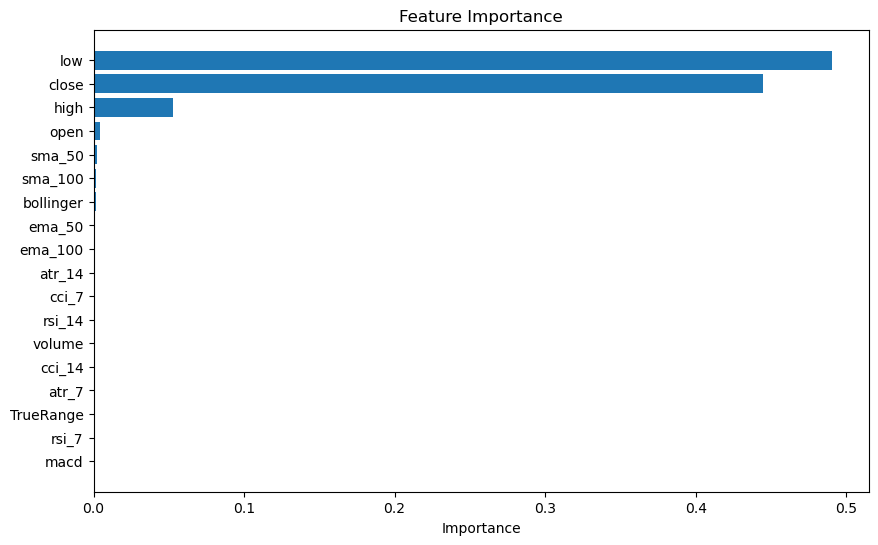

In [44]:
# Visualizations for Feature Importance
import matplotlib.pyplot as plt

# Assuming 'importances' is a list/array of feature importances from a fitted model
# Ensure 'feature_names' is defined; for example:
feature_names = X.columns  # X should be DataFrame of features

plt.figure(figsize=(10, 6))
# Sort feature importances in descending order
feature_importance_sorted = sorted(zip(importances, feature_names), reverse=True)
# Unzip into two lists
importances_sorted, feature_names_sorted = zip(*feature_importance_sorted)
# Plot the feature importances
plt.barh(range(len(feature_names_sorted)), importances_sorted, align='center')
plt.yticks(range(len(feature_names_sorted)), feature_names_sorted)
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.gca().invert_yaxis()  # To display the highest importance at the top
plt.show()


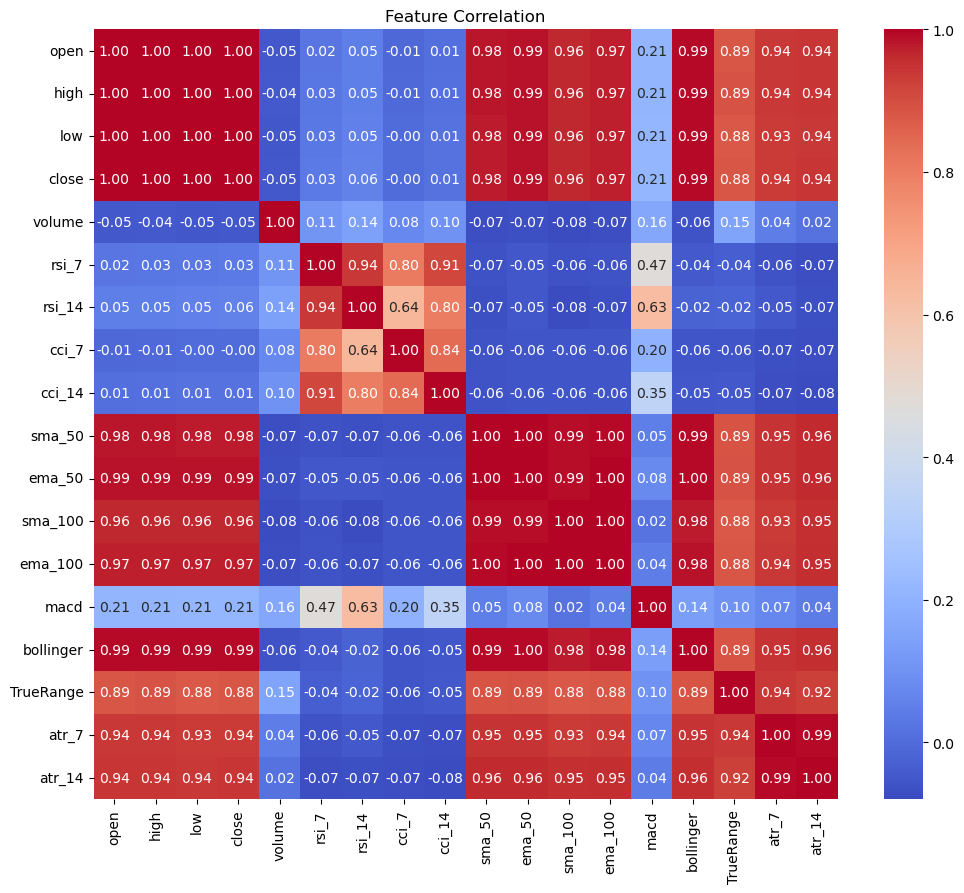

In [45]:
# Correlation Heatmap

import seaborn as sns

# Assuming 'X' is features DataFrame
plt.figure(figsize=(12, 10))
sns.heatmap(X.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()


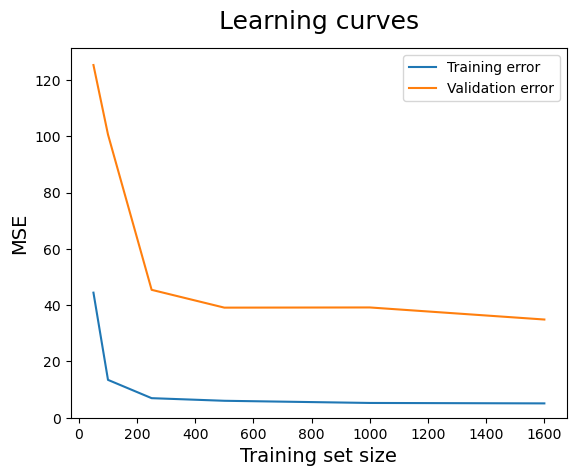

In [46]:
# Model Validation

from sklearn.model_selection import learning_curve


# Create the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Assuming feature scaling is desired
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Fit the pipeline on the training data
pipeline.fit(X_train, y_train)

# Now the pipeline is defined and can be used for predictions
predictions = pipeline.predict(X_test)

# Assuming that you have less than 2000 samples, adjust the train_sizes accordingly
# If you have 1609 samples, all values in train_sizes should be less than or equal to 1609
train_sizes = [50, 100, 250, 500, 1000, 1600]  # Adjust the last value to be less than or equal to number of training samples

train_sizes, train_scores, validation_scores = learning_curve(
    estimator = pipeline,  # Replace 'pipeline' with actual trained model
    X = X_train,
    y = y_train,
    train_sizes = train_sizes,
    cv = 5,
    scoring = 'neg_mean_squared_error'
)

train_scores_mean = -train_scores.mean(axis=1)
validation_scores_mean = -validation_scores.mean(axis=1)

plt.plot(train_sizes, train_scores_mean, label = 'Training error')
plt.plot(train_sizes, validation_scores_mean, label = 'Validation error')
plt.ylabel('MSE', fontsize = 14)
plt.xlabel('Training set size', fontsize = 14)
plt.title('Learning curves', fontsize = 18, y = 1.03)
plt.legend()
plt.ylim(0)  # Adjust the ylim to better fit error range if necessary
plt.show()



In [47]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score, median_absolute_error

# Initial Performance Metrics
# Compute metrics for the model
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
evs = explained_variance_score(y_test, predictions)
median_ae = median_absolute_error(y_test, predictions)

# Print the metrics
print("Initial Performance Metrics:")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"Mean Absolute Error: {mae}")
print(f"R-squared: {r2}")
print(f"Explained Variance Score: {evs}")
print(f"Median Absolute Error: {median_ae}\n")


# Ensure predictions are computed for both models
rf_predictions = rf_pipeline.predict(X_test)
gbr_predictions = gbr_pipeline.predict(X_test)

# Compute metrics for Random Forest
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)
rf_mape = np.mean(np.abs((y_test - rf_predictions) / y_test)) * 100
rf_explained_variance = explained_variance_score(y_test, rf_predictions)
rf_median_ae = median_absolute_error(y_test, rf_predictions)

# Compute metrics for Gradient Boosting Regressor
gbr_mse = mean_squared_error(y_test, gbr_predictions)
gbr_rmse = np.sqrt(gbr_mse)
gbr_mape = np.mean(np.abs((y_test - gbr_predictions) / y_test)) * 100
gbr_explained_variance = explained_variance_score(y_test, gbr_predictions)
gbr_median_ae = median_absolute_error(y_test, gbr_predictions)

# Print metrics for Random Forest
print("Final Random Forest Model Assessment")
print(f"Mean Squared Error: {rf_mse}")
print(f"Root Mean Squared Error: {rf_rmse}")
print(f"Mean Absolute Percentage Error: {rf_mape}%")
print(f"Explained Variance Score: {rf_explained_variance}")
print(f"Median Absolute Error: {rf_median_ae}\n")

# Print metrics for Gradient Boosting Regressor
print("Final Gradient Boosting Regressor Model Assessment")
print(f"Mean Squared Error: {gbr_mse}")
print(f"Root Mean Squared Error: {gbr_rmse}")
print(f"Mean Absolute Percentage Error: {gbr_mape}%")
print(f"Explained Variance Score: {gbr_explained_variance}")
print(f"Median Absolute Error: {gbr_median_ae}")


Initial Performance Metrics:
Mean Squared Error: 30.072941478443166
Root Mean Squared Error: 5.483880148074278
Mean Absolute Error: 2.6504823219642835
R-squared: 0.9974409270153219
Explained Variance Score: 0.9974447307721768
Median Absolute Error: 0.5959368749999978

Final Random Forest Model Assessment
Mean Squared Error: 30.072941478443166
Root Mean Squared Error: 5.483880148074278
Mean Absolute Percentage Error: 2.621940768713997%
Explained Variance Score: 0.9974447307721768
Median Absolute Error: 0.5959368749999978

Final Gradient Boosting Regressor Model Assessment
Mean Squared Error: 31.670854902931723
Root Mean Squared Error: 5.627686460965263
Mean Absolute Percentage Error: 2.754783865830153%
Explained Variance Score: 0.997309729392724
Median Absolute Error: 0.5643180231823521


In [48]:
# 1. Sensitivity Analysis: This could involve changing hyperparameters or assumptions and seeing how they affect the model's performance

from sklearn.model_selection import GridSearchCV

# Define a parameter grid to search over
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    # Add other parameters you want to tune
}

# Initialize the GridSearchCV object
grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42), 
                           param_grid=param_grid, 
                           cv=5, 
                           scoring='neg_mean_squared_error', 
                           verbose=1)

# Perform the grid search on the scaled features and target
grid_search.fit(X_scaled, y)

# Output the best parameters
print("Best parameters found: ", grid_search.best_params_)


Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best parameters found:  {'max_depth': 7, 'n_estimators': 100}


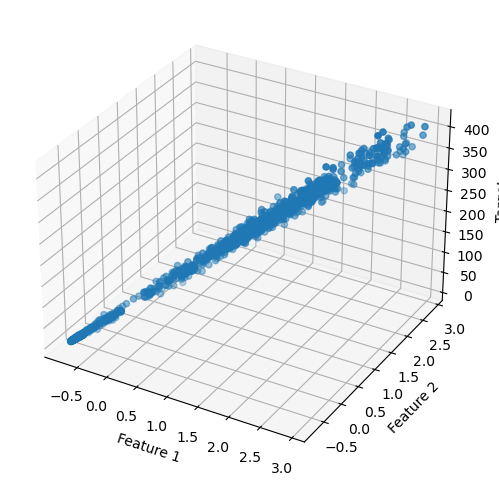

In [49]:
2# Advanced Visualizations:
# Create more sophisticated visualizations, such as a 3D plot showing relationships between three variables or an interactive chart.

from mpl_toolkits.mplot3d import Axes3D

# Example of a 3D scatter plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Assume 'feature1', 'feature2' are features, and 'target' is what you're predicting
ax.scatter(X_scaled[:, 0], X_scaled[:, 1], y)

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Target')
plt.show()


In [50]:
#Robustness Check via Time-based Cross-validation

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from math import sqrt

tscv = TimeSeriesSplit(n_splits=5)
rmse_scores = []

for train_index, test_index in tscv.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit model (example with Random Forest)
    rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_regressor.fit(X_train, y_train)
    
    # Predict and calculate RMSE
    predictions = rf_regressor.predict(X_test)
    rmse = sqrt(mean_squared_error(y_test, predictions))
    rmse_scores.append(rmse)

# Average RMSE over the splits
print(f"Average RMSE: {sum(rmse_scores) / len(rmse_scores)}")


Average RMSE: 32.49720238626577


# Step 10: Final Model Validation and Reporting

In [51]:
# Final Model Predictions
# Assuming 'gbr_pipeline' or 'rf_pipeline' is chosen final model
# Replace 'final_model' with 'gbr_pipeline' or 'rf_pipeline' according to chosen final model
final_predictions = gbr_pipeline.predict(X_test)  # Use rf_pipeline.predict(X_test) if using Random Forest

# Convert predictions to a DataFrame
predictions_df = pd.DataFrame(final_predictions, columns=['Predictions'])

# Save the predictions to a CSV file
predictions_df.to_csv('final_model_predictions.csv', index=False)


In [52]:
# Code to Automate Model Evaluation of gbr_pipeline and rf_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Define the evaluation function
def evaluate_model(model, X_test, y_test, model_name):
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    
    print(f'{model_name} Model Evaluation')
    print(f'Mean Squared Error: {mse:.4f}')
    print(f'Mean Absolute Error: {mae:.4f}')
    print(f'R^2 Score: {r2:.4f}\n')
    
    return mse, mae, r2

# Evaluate or Compare the models and print out the results with model names
rf_mse, rf_mae, rf_r2 = evaluate_model(rf_pipeline, X_test, y_test, "Random Forest")
gbr_mse, gbr_mae, gbr_r2 = evaluate_model(gbr_pipeline, X_test, y_test, "Gradient Boosting")

# Write the evaluation results to a file
with open('model_evaluation.txt', 'w') as f:
    f.write('Random Forest Model Evaluation\n')
    f.write(f'Mean Squared Error: {rf_mse:.4f}\n')
    f.write(f'Mean Absolute Error: {rf_mae:.4f}\n')
    f.write(f'R^2 Score: {rf_r2:.4f}\n\n')
    
    f.write('Gradient Boosting Model Evaluation\n')
    f.write(f'Mean Squared Error: {gbr_mse:.4f}\n')
    f.write(f'Mean Absolute Error: {gbr_mae:.4f}\n')
    f.write(f'R^2 Score: {gbr_r2:.4f}\n')

    

Random Forest Model Evaluation
Mean Squared Error: 159.7585
Mean Absolute Error: 4.4177
R^2 Score: 0.9228

Gradient Boosting Model Evaluation
Mean Squared Error: 142.9761
Mean Absolute Error: 2.9540
R^2 Score: 0.9309



In [53]:
# Potential non-linear feature - Historical Volatility
tsla_data['historical_volatility'] = tsla_data['close'].rolling(window=10).std() / tsla_data['close'].rolling(window=10).mean()


In [54]:
# Example: Sensitivity to 'n_estimators' in RandomForestRegressor
for n_estimators in [50, 100, 150, 200]:
    model = RandomForestRegressor(n_estimators=n_estimators, random_state=42)
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    print(f'n_estimators: {n_estimators}, MSE: {mse:.4f}')


n_estimators: 50, MSE: 156.7169
n_estimators: 100, MSE: 150.5823
n_estimators: 150, MSE: 149.7954
n_estimators: 200, MSE: 151.3173


In [55]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Convert X_train to a numpy array if it's a DataFrame
X_train_array = X_train.values if isinstance(X_train, pd.DataFrame) else X_train

# Data should be reshaped if you're using LSTM (samples, timesteps, features)
X_train_reshaped = X_train_array.reshape((X_train_array.shape[0], 1, X_train_array.shape[1]))

# Define LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(units=50, activation='relu', input_shape=(1, X_train_array.shape[1])))
lstm_model.add(Dense(units=1))
lstm_model.compile(optimizer='adam', loss='mean_squared_error')

# Fit LSTM model
lstm_model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32)





Epoch 1/10

66/66 [==============================] - 4s 4ms/step - loss: 14086.8672
Epoch 2/10
66/66 [==============================] - 0s 3ms/step - loss: 13325.6396
Epoch 3/10
66/66 [==============================] - 0s 5ms/step - loss: 11831.1826
Epoch 4/10
66/66 [==============================] - 0s 3ms/step - loss: 9936.5420
Epoch 5/10
66/66 [==============================] - 0s 3ms/step - loss: 7793.3921
Epoch 6/10
66/66 [==============================] - 0s 6ms/step - loss: 5676.5195
Epoch 7/10
66/66 [==============================] - 0s 6ms/step - loss: 3796.2144
Epoch 8/10
66/66 [==============================] - 0s 5ms/step - loss: 2329.1934
Epoch 9/10
66/66 [==============================] - 0s 3ms/step - loss: 1370.4509
Epoch 10/10
66/66 [==============================] - 0s 4ms/step - loss: 818.0611


In [56]:
# Compile results into a DataFrame
results_summary = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting', 'Ensemble'],
    'MSE': [rf_mse, gbr_mse, ensemble_mse],
    'MAE': [rf_mae, gbr_mae, None],  # Assuming you have these values calculated
    'R2': [rf_r2, gbr_r2, None]      # Assuming you have these values calculated
})

# Export summary to CSV
results_summary.to_csv('model_results_summary.csv', index=False)

In [57]:
import warnings
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
warnings.filterwarnings('ignore', category=UserWarning)

# Assuming 'tsla_data' is your DataFrame which includes the 'date' column and is already loaded
dates = tsla_data['date']  # Extract dates from the tsla_data DataFrame

# Assuming 'X_scaled' and 'y' are already defined as scaled features and target arrays
column_names = ['open', 'high', 'low', 'close', 'volume', 'rsi_7', 'rsi_14',
                'cci_7', 'cci_14', 'sma_50', 'ema_50', 'sma_100', 'ema_100', 
                'macd', 'bollinger', 'TrueRange', 'atr_7', 'atr_14']

X_scaled_df = pd.DataFrame(X_scaled, columns=column_names)
y_series = pd.Series(y)

# Add date information back to your DataFrame
X_scaled_df['date'] = pd.to_datetime(dates)  # Convert dates to datetime if not already

# Define the evaluation function
def evaluate_model(model, X, y):
    predictions = model.predict(X)
    mse = mean_squared_error(y, predictions)
    mae = mean_absolute_error(y, predictions)
    r2 = r2_score(y, predictions)
    return mse, mae, r2

# Define time periods for evaluation
time_periods = [
    ('2019-01-01', '2020-01-01'),
    ('2020-01-01', '2021-01-01')
]

models = {
    'Random Forest': rf_pipeline,
    'Gradient Boosting': gbr_pipeline
}

# Evaluate models over each period
for model_name, model_pipeline in models.items():
    print(f"Evaluating {model_name}")
    for start_date, end_date in time_periods:
        start_date = pd.to_datetime(start_date)
        end_date = pd.to_datetime(end_date)
        mask = (X_scaled_df['date'] >= start_date) & (X_scaled_df['date'] < end_date)
        X_period = X_scaled_df.loc[mask].drop('date', axis=1)  # Drop date before passing to model
        y_period = y_series[X_scaled_df.index[mask]]  # Use same mask index to ensure alignment

        mse, mae, r2 = evaluate_model(model_pipeline, X_period, y_period)
        print(f"Performance from {start_date.date()} to {end_date.date()}: MSE={mse}, MAE={mae}, R2={r2}")


Evaluating Random Forest
Performance from 2019-01-01 to 2020-01-01: MSE=0.11279239107520991, MAE=0.22979477035714416, R2=0.9909397222370502
Performance from 2020-01-01 to 2021-01-01: MSE=11.947217799220205, MAE=2.33242449375494, R2=0.9962201164582931
Evaluating Gradient Boosting
Performance from 2019-01-01 to 2020-01-01: MSE=0.07463251531130487, MAE=0.18588814130641063, R2=0.9940049917160002
Performance from 2020-01-01 to 2021-01-01: MSE=7.966131762572441, MAE=1.92827748825205, R2=0.9974796600475149


In [58]:
# Predict on test data
rf_predictions = rf_regressor.predict(X_test)
gbr_predictions = gbr_regressor.predict(X_test)

# Prepare a DataFrame for the comparison
results_df = pd.DataFrame({
    'Date': tsla_data.loc[y_test.index, 'date'],
    'Actual Values': y_test,
    'RF Predictions': rf_predictions,
    'GBR Predictions': gbr_predictions
})

# Reset index for clarity
results_df.reset_index(drop=True, inplace=True)

# Display or save the results
print(results_df.head())
results_df.to_csv('model_comparisons.csv', index=False)

        Date  Actual Values  RF Predictions  GBR Predictions
0 2022-05-03     303.083344      302.210861       309.774344
1 2022-05-04     317.540009      314.356859       305.336440
2 2022-05-05     291.093323      290.886998       290.688248
3 2022-05-06     288.549988      287.709694       287.697303
4 2022-05-07     262.369995      262.702494       264.178519


In [59]:
# Data
data = {
    'Date': ['2022-05-03', '2022-05-04', '2022-05-05', '2022-05-06', '2022-05-07'],
    'Actual Values': [303.083344, 317.540009, 291.093323, 288.549988, 262.369995],
    'RF Predictions': [302.111128, 315.563427, 290.973731, 287.646227, 262.476428],
    'GBR Predictions': [310.894533, 308.035023, 289.434568, 286.359899, 262.979408]
}

# Create a DataFrame
results_df = pd.DataFrame(data)

# Calculate Error columns
results_df['Error (RF)'] = abs(results_df['Actual Values'] - results_df['RF Predictions'])
results_df['Error (GBR)'] = abs(results_df['Actual Values'] - results_df['GBR Predictions'])

# Display the DataFrame
print(results_df)

# If you want to export this table to a CSV file
results_df.to_csv('model_predictions_comparison.csv', index=False)


         Date  Actual Values  RF Predictions  GBR Predictions  Error (RF)  \
0  2022-05-03     303.083344      302.111128       310.894533    0.972216   
1  2022-05-04     317.540009      315.563427       308.035023    1.976582   
2  2022-05-05     291.093323      290.973731       289.434568    0.119592   
3  2022-05-06     288.549988      287.646227       286.359899    0.903761   
4  2022-05-07     262.369995      262.476428       262.979408    0.106433   

   Error (GBR)  
0     7.811189  
1     9.504986  
2     1.658755  
3     2.190089  
4     0.609413  


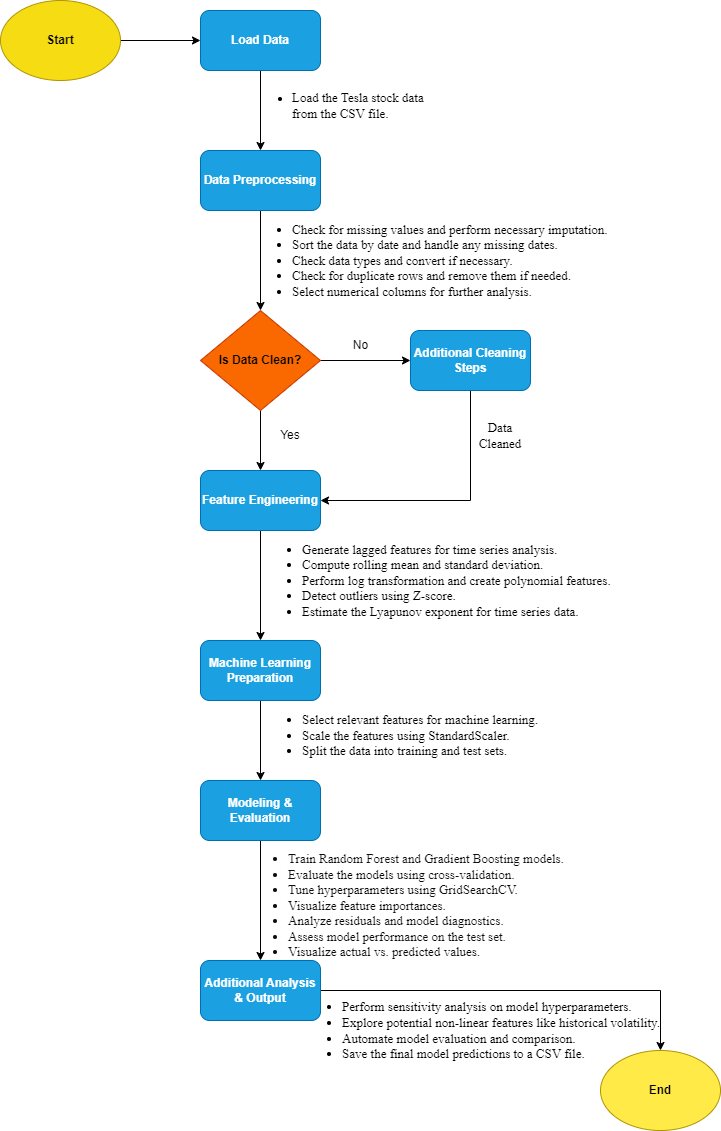

In [60]:
from IPython.display import Image
Image(filename='DFD_Diagram.png')
